# Preprocessing & Feature Engineering 

## 0- Import Libraries

In [120]:
# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif, SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

## 1- Import cleaned dataset

In [121]:
# import cleaned data of cleveland
#features = pd.read_csv("../data/02_cleaned/cleaned_dataframe.csv")
features = pd.read_csv("../data/01_raw/raw_dataframe.csv")

# dataset overview
features.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       303 non-null    int64  
 1   Sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


### Overview of the dataset

In [122]:
features.describe()

,Age,Sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## 2- Handle missing values

### Check missing values

In [123]:
features.isnull().sum()

Age         0
Sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

From the dataset `ca` and `thal` variable have missing values, other variables with no missing values.

## 3- Data Imputation

In [124]:
print(features.columns)

Index(['Age', 'Sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [125]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# clean column name
features.columns = features.columns.str.strip().str.lower()

features = features.replace('?', np.nan)

# replace missing values
features_clean.replace('?', np.nan, inplace=True)

# convert numeric columns
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
features[num_cols] = features[num_cols].apply(pd.to_numeric, errors='coerce')

# Impute
Imputer = SimpleImputer(strategy="median")
features[num_cols] = Imputer.fit_transform(features[num_cols])


## 4- Encode categorical features

Although several variables were stored as numeric types, such as **(`sex`, `cp`[chest pain], `fbs`[fasting blood sugar], `restcg`, `examg`, `slope`, `thal`)**. These variable were therefore treated as categorical and encoded using-hot enconding to avoid introducing artificial ordinal relationship.

We used [get.dummies()](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) to convert categorical variable into dummy/indicator varianle

In [126]:
# Identify categorical variavels
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

# convert to categorical 
#features_clean[cat_cols] = features_clean[cat_cols].astype("category")

# apply encoding
features_encoded = pd.get_dummies(features, columns = cat_cols, drop_first = True)

# print results
print("Encoded dataset shape:", features_clean_encoded.shape)
print("\nNew columns:\n", features_clean_encoded.columns)

Encoded dataset shape: (303, 18)

New columns:
 Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex_1.0',
       'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_1.0', 'restecg_1.0', 'restecg_2.0',
       'exang_1.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0'],
      dtype='object')


After encoding the dataset contained 18 features, including both numerical variables and one-hot encoded categorical variable.

## 5- Feature Scaling and Standardization

Standardization was applied using the `StandardScaler` from `sklearn`. This method subtract the mean and divides by standard deviation for each feature, resulting in variable with zero mean and unit variance

In [127]:
from sklearn.preprocessing import StandardScaler

X = features_encoded.drop("target", axis=1)
y = features_encoded["target"]


scaler = StandardScaler() # This creates a new OBJECT that has methods and attributes
X_scaled = scaler.fit_transform(X)

print("Means:", scaler.mean_)
print("Variances:", scaler.var_)

Means: [5.44389439e+01 1.31689769e+02 2.46693069e+02 1.49607261e+02
 1.03960396e+00 6.63366337e-01 6.79867987e-01 1.65016502e-01
 2.83828383e-01 4.75247525e-01 1.48514851e-01 1.32013201e-02
 4.88448845e-01 3.26732673e-01 4.62046205e-01 6.93069307e-02
 5.94059406e-02 3.86138614e-01]
Variances: [8.14277903e+01 3.08728839e+02 2.67200150e+03 5.21538825e+02
 1.34364605e+00 8.70176127e-01 2.17647507e-01 1.37786056e-01
 2.03269832e-01 2.49387315e-01 1.26458190e-01 1.30270453e-02
 2.49866571e-01 2.19978433e-01 2.48559509e-01 6.45034801e-02
 5.58768748e-02 2.37035585e-01]


The computer **means and variances** show substantial differences in the scale of the variables, with some features exhibiting significantly larger variability than others. This imbalance would bias distance-based methods such as PCA. Therefore, standardization was applied to normalize all features to a common scale, ensuring that no single variable dominates the analysis.

# Step A: Principal Component Analysis

In [128]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(explained)
print(cumulative)

[0.18995818 0.09332318 0.08128874 0.07471348 0.07281696 0.06712585
 0.05742977 0.0503162  0.04825454 0.0451006  0.04313879 0.03957069
 0.03807293 0.03102809 0.02313375 0.02220122 0.01657576 0.00595127]
[0.18995818 0.28328136 0.3645701  0.43928358 0.51210054 0.57922639
 0.63665616 0.68697236 0.7352269  0.7803275  0.82346629 0.86303698
 0.9011099  0.932138   0.95527175 0.97747297 0.99404873 1.        ]


from the output: 
PC1 &asymp; 19%, captures the most variation
PC2 &asymp; 9% and PC3 &asymp; 8%
The variance is spread across many components

### **Plot explained variance per component**

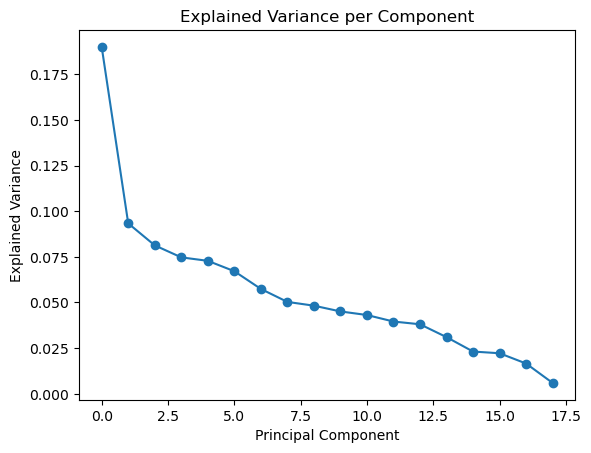

In [129]:
import matplotlib.pyplot as plt

plt.plot(explained, marker='o')
plt.title("Explained Variance per Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.show()

We see that Sharp drop from PC1 to PC2, it means gradual decline, no very strong **elbow**.
The dataset does not have a very low intrinsic dimensionality

### **Plot cumulative variance** 

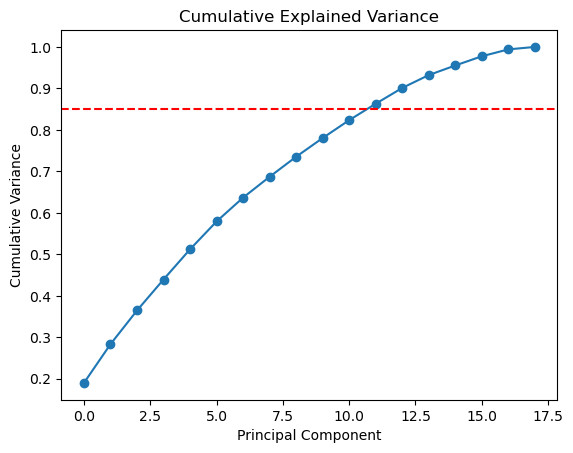

In [130]:
plt.plot(cumulative, marker='o')
plt.axhline(y=0.85, color='r', linestyle='--') # threshold at 85%
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.show()

The cumulative explained variance plot shows that approximately 11 principal components are required to retain at least 85% of the total variance in the dataset. This show that the dataset does not have a strong low-dimensional structure and that several components are needed to adequately capture the variability in the data
The absence of a clear elbow point further suggest that the data not exhibit strong redundancy and multiple dimensions are required to represent its structure

### **Select components ($\geq$ 85\%)**

In [131]:
n_components = np.argmax(cumulative >= 0.85) + 1
print("Number of components (≥ 85% variance):", n_components)

Number of components (≥ 85% variance): 12


### **Visualize first two principal components**

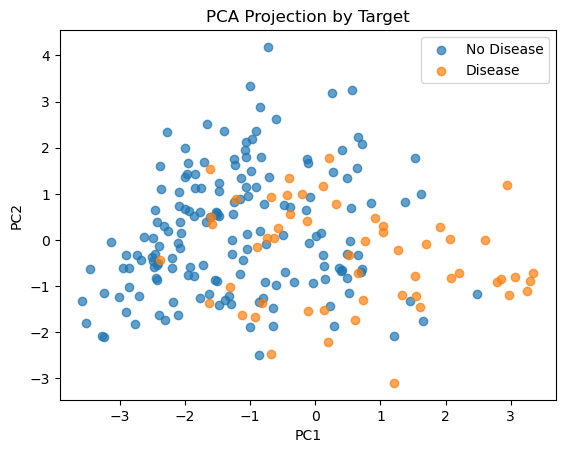

In [132]:
plt.figure()

# Plot each class separately
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.7, label="No Disease")
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.7, label="Disease")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection by Target")
plt.legend()

plt.show()

- The PCA projection was colored according to the target variable, where `0` represents absence of heart disease and `1` represents presence of disease.\
- The overlap between classes indicates that the first two principal components do not clearly separate the two groups.

# STEP B - Feature selection supervised

## Extract target 
The `Target` is the diagnosis of heart disease, the original variable name is `num`.

In [133]:
y = features["target"]
# convert to binary classification
y = (y>0).astype(int)

### Train -test split

In [134]:
# import function to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Split features (X) and target (y) into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
X, y,                 # input features and target variable
test_size = 0.2,      # 20% of data used for testing
random_state = 42,    # ensures reproducibility of results 
stratify = y          # preserves class distribution in both sets
)

## ANOVA F-Test (Univariate)
For **Univariate method** we will use **ANOVA F-test**  selected the most relevant features based on their statistical relationship with the target variable.

In [135]:
# Import feature selection tools/library
from sklearn.feature_selection import SelectKBest, f_classif

k = 8     # define number of features to select 

# initiate SelectKBest  using ANOVA F-test (f_classif), this evaluate each feature independently against the target
selector = SelectKBest(score_func = f_classif, k = k)

# fit selector on training data
X_train_kbest = selector.fit_transform(X_train, y_train)

# apply same transformation to test data
X_test_kbest = selector.transform(X_test)

# get names of selected features
selected_features_kbest = X.columns[selector.get_support()]

# print selected features
print("\nSelected features (ANOVA F-Test):")
print(selected_features_kbest)


Selected features (ANOVA F-Test):
Index(['thalach', 'oldpeak', 'ca', 'sex_1', 'cp_4', 'exang_1', 'slope_2',
       'thal_7.0'],
      dtype='object')


The selected features include both numerical variables (such as thalach, oldpeak, and ca) and encoded categorical variables (such as cp, exang, and thal). These variables are clinically meaningful and are known to be strong indicators of heart disease.

For instance, ST depression (oldpeak) and the number of major vessels (ca) are key diagnostic indicators, while maximum heart rate (thalach) reflects cardiovascular performance. The inclusion of categorical features such as chest pain type and exercise-induced angina further supports the model's ability to distinguish between patients with and without heart disease.

## F-Scores

In [136]:
# creation of a dataframe with feature names and their F-score
anova_results = pd.DataFrame({
    "feature": X.columns,                       # original features name
    "F_score": selector.scores_                 # corresponding ANOVA scores
}).sort_values(by = "F_score", ascending=False) # Sort from most to least important

# print ranked features
print("n\Feature ranking:")
print(anova_results)

n\Feature ranking:
      feature    F_score
17   thal_7.0  87.411429
9        cp_4  74.537907
5          ca  60.252389
13    exang_1  51.486909
3     thalach  48.347133
4     oldpeak  43.615028
14    slope_2  31.826854
6       sex_1  25.215352
8        cp_3  18.859468
7        cp_2  18.654068
0         age  11.035221
12  restecg_2   6.621067
1    trestbps   4.528441
16   thal_6.0   1.462084
2        chol   1.438593
11  restecg_1   0.846790
15    slope_3   0.739908
10      fbs_1   0.506449


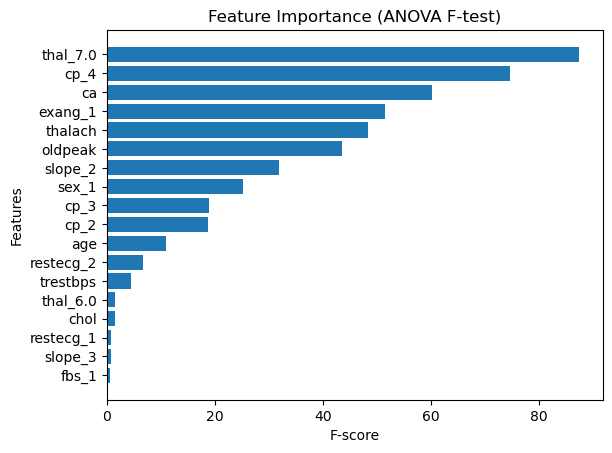

In [137]:
# plot 
import matplotlib.pyplot as plt

plt.figure()

# Sort features (lowest → highest for better visualization)
anova_results_sorted = anova_results.sort_values(by="F_score", ascending=True)

plt.barh(anova_results_sorted["feature"], anova_results_sorted["F_score"])

plt.title("Feature Importance (ANOVA F-test)")
plt.xlabel("F-score")
plt.ylabel("Features")

plt.show()

The results show that features such as **thal_7.0**, **cp_4.0**, and **ca** have the highest F-scores, indicating strong discriminatory power.

In particular, thalassemia status (thal) and chest pain type (cp) emerge as the most influential categorical variables, while the number of major vessels (ca) is a key clinical indicator. Additional variables such as exercise-induced angina (exang), maximum heart rate (thalach), and ST depression (oldpeak) also show substantial importance.

Conversely, variables such as cholesterol (chol), resting blood pressure (trestbps), and fasting blood sugar (fbs) exhibit low F-scores, suggesting limited contribution to class separation in this dataset.

The plot confirms that a subset of features carries most of the predictive information, supporting the use of feature selection to reduce dimensionality while preserving interpretability.

## Wrapper Method (Multivariate)
### Forward feature selection  

In [138]:
# Import wrapper libraries and model
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
import numpy as np

# define model used to evaluate feature subsets
model = LogisticRegression(max_iter=1000)

# initialize sequential feature selector
sfs = SequentialFeatureSelector(
    model,                        # model used to evaluate feature subsets
    n_features_to_select=k,       # number of features to select
    direction="forward",          # start with no features and add one by one
    scoring="accuracy",           # evaluation metric
    cv=5,                         # 5-fold cross-validation
    n_jobs=1                       # all available CPU cores
)

# fit forward selection on training data
sfs.fit(X_train, y_train)

# get selected feature names
selected_sfs = X.columns[sfs.get_support()]

# print selected features
print("\nSelected features (Forward Selection):")
print(selected_sfs)





Selected features (Forward Selection):
Index(['age', 'thalach', 'ca', 'sex_1', 'cp_2', 'cp_4', 'fbs_1', 'thal_7.0'], dtype='object')


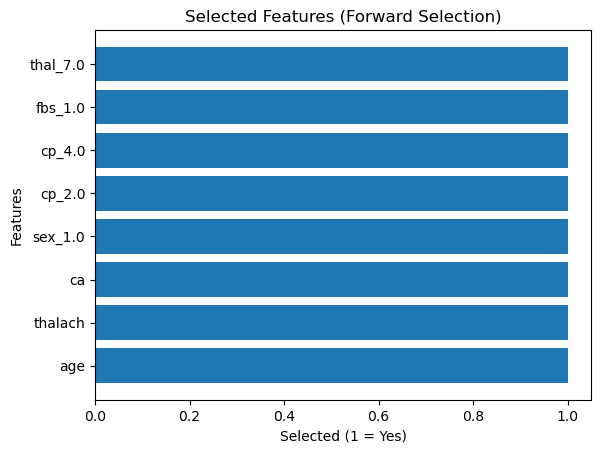

In [139]:
# Keep only selected features
selected_wrapper_df = wrapper_df[wrapper_df["Selected"] == 1]

plt.figure()

plt.barh(selected_wrapper_df["Feature"], selected_wrapper_df["Selected"])

plt.title("Selected Features (Forward Selection)")
plt.xlabel("Selected (1 = Yes)")
plt.ylabel("Features")

plt.show()

## Comparison between ANOVA and Wrapper Method

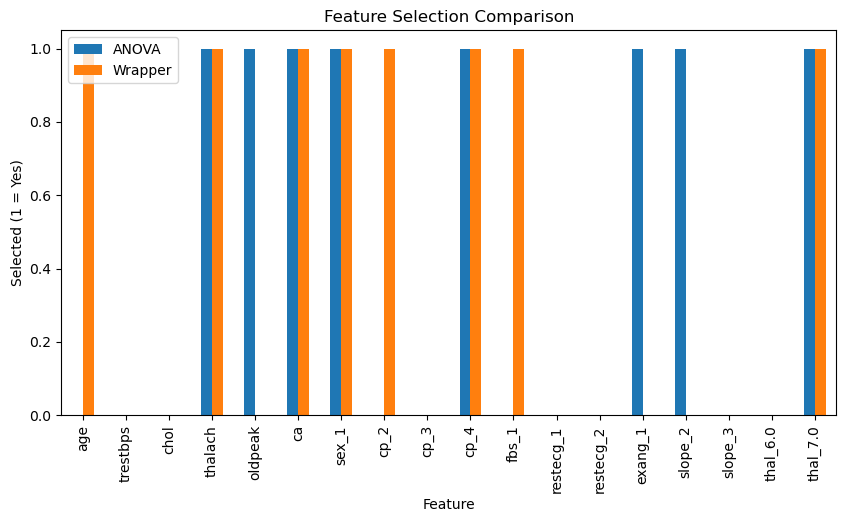

In [140]:

comparison_df = pd.DataFrame({
    "Feature": X.columns,
    "ANOVA": X.columns.isin(selected_features_kbest).astype(int),
    "Wrapper": X.columns.isin(selected_sfs).astype(int)
})

comparison_df.set_index("Feature").plot(kind="bar", figsize=(10,5))

plt.title("Feature Selection Comparison")
plt.ylabel("Selected (1 = Yes)")
plt.xticks(rotation=90)
plt.show()

- Some features are consistently selected by both methods, indicating strong relevance, while others differ due to the wrapper method’s ability to capture interactions between variables.
- Many features were consistently selected by both methods, including `thalach`, `ca`, `cp_4.0`, and `thal_7.0`, indicating that these variables have strong predictive power and a stable relationship with the target variable. The agreement between methods increases confidence in their relevance.

- However, some features were selected by only one method. For example, ANOVA selected features such as exang_1.0 and slope_2.0, while the wrapper method selected features like cp_2.0 and fbs_1.0. This difference arises because ANOVA evaluates each feature independently, while forward selection considers interactions between features within a predictive model.

## Final Feature set

In [142]:
# selected final feature subset based on ANOVA results 
X_selected = X[selected_features_kbest]

# print shape of final dataset
print("\nFinal feature shape:", X_selected.shape)


Final feature shape: (303, 8)


## # Export selected features dataset to CSV

In [ ]:
from pathlib import Path
import pandas as pd

# Create output folder named 03_selected
output_dir = Path("../data/03_selected")
output_dir.mkdir(parents=True, exist_ok=True)

selected_with_target = X_selected.copy()
selected_with_target["target"] = y.values

selected_with_target.to_csv(output_dir / "selected_features_with_target.csv", index=False)

* Following feature selection, the dataset was reduced to **8** features while preserving all **303** observations. This dimensionality reduction removes irrelevant and redundant variables, improving model efficiency and interpretability. The selected features represent the most informative variables for distinguishing between patients with and without heart disease.

## Conclusion

The **ANOVA F-test** was used as a feature selection method to identify the most relevant variables prior to clustering. It evaluates each feature independently based on its statistical relationship with the target variable. The top-ranked features were then retained and used as input for the clustering algorithm. This approach ensures that clustering is performed on the most informative and discriminative variables, improving both interpretability and performance.

**Note**
* PCA was used to explore the structure of the dataset and revealed that the data is high-dimensional and complex. 
* Feature selection methods were then applied to identify a reduced set of meaningful and interpretable variables.
* The final selection of 8 features balances dimensionality reduction with interpretability and statistical relevance, providing a strong foundation for subsequent clustering analysis.

## Summary of steps performed
**1- Data preprocessing**\
* Loading a dataset using **pandas**
* Checking for **missing values** and dataset **shape**
* Understanding dataset structure with `.info()` and `.describe()`

 **2- Encoding of categorical variables**\
 **3- Standardization, check scaling**\
**4- Target Variable Preparation**\
### Step A:  Principal Component Analysis (PCA)**
**6- Screen Plot**\
**7-Cumulative Variance Plot**\
**8-PCA Projection with target**\
### Step B Feature Selection
**9- Split dataset in Training and Test**\
**10- Filter Method- AVOVA F-Test**\
**11- Feature score (F-score) and Plot**\
**12- Wrapper Method - Forward feature selection and Plot**\
**13- Comparasion plot of ANOVA and Wrapper Method**\
**14- Final feature set**\

### Export selected feature
### Conclusion




